# Supplementary Figure S4(D) — Geometric-defect prevalence by tier

Issue prevalence in priority-review vs secondary-review pairs.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
LW = ["cWW", "tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


CUT = 75


WEIGHTS = json.load(open(data_file("reference/scoring_tables/penalty_weights.json")))["penalty_weights"]


ISSUES = list(WEIGHTS)


def scored_pairs(lw_only=True):
    """Unambiguous, scored per-pair records. lw_only keeps the 12 canonical LW classes."""
    raw = pd.DataFrame(json.loads(l) for l in open(data_file("reference/scores/pair_scores_uniques_parse.jsonl")))
    df = raw[~raw["is_ambiguous"] & raw["score"].notna()].copy()
    if lw_only:
        df = df[df["lw_class"].isin(LW)].copy()
    return df


def add_tier(df):
    """Add a 'tier' column: Preferred (=100) / Acceptable [75,100) / Review (<75)."""
    df = df.copy()
    df["issues"] = df["issues"].apply(lambda d: d if isinstance(d, dict) else {})
    df["tier"] = np.where(df["score"] >= 99.995, "Preferred",
                          np.where(df["score"] >= CUT, "Acceptable", "Review"))
    return df

saved figures/figS4_D_issue_prevalence_by_tier.png


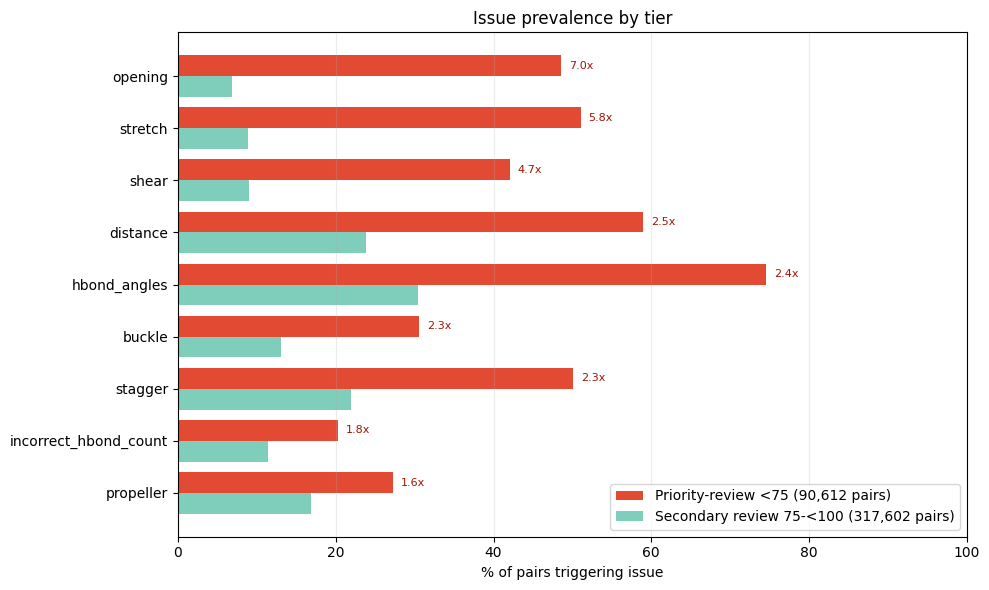

In [3]:
df = add_tier(scored_pairs(lw_only=False))
def _freq(sub):
    m = len(sub); c = {k: 0 for k in ISSUES}
    for iss in sub['issues']:
        for k in iss: c[k] += 1
    return ({k: 100*c[k]/m for k in ISSUES} if m else {k: 0 for k in ISSUES}), m
fr_R, nR = _freq(df[df['tier'] == 'Review'])
fr_A, nA = _freq(df[df['tier'] == 'Acceptable'])
enr = {k: (fr_R[k]/fr_A[k] if fr_A[k] else 0) for k in ISSUES}
row = sorted(ISSUES, key=lambda k: enr[k])
y = np.arange(len(row)); h = 0.4
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + h/2, [fr_R[k] for k in row], h, color='#e34a33', label=f'Priority-review <75 ({nR:,} pairs)')
ax.barh(y - h/2, [fr_A[k] for k in row], h, color='#7fcdbb', label=f'Secondary review 75-<100 ({nA:,} pairs)')
for i, k in enumerate(row):
    ax.text(fr_R[k] + 1, i + h/2, f'{enr[k]:.1f}x', va='center', fontsize=8, color='#a01500')
ax.set_yticks(y); ax.set_yticklabels(row)
ax.set_xlabel('% of pairs triggering issue'); ax.set_title('Issue prevalence by tier')
ax.set_xlim(0, 100); ax.legend(loc='lower right'); ax.grid(alpha=0.25, axis='x')
fig.tight_layout(); print('saved', savefig(fig, 'figS4_D_issue_prevalence_by_tier.png')); plt.show()